In [4]:
# -*- coding: utf-8 -*-
"""Analise_Marketing.ipynb"""

# ==========================================
# Importações
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [5]:
# ==========================================
# 1. Carregamento e Preparação Inicial
# ==========================================
dados = pd.read_csv('marketing.csv')

# Criação das variáveis derivadas
dados['taxa_cliques'] = dados['cliques'] / dados['anuncios']
dados['relevante'] = dados['taxa_cliques'] > 3

# Ordenação para visualização inicial
dados.sort_values(by="taxa_cliques", ascending=False, inplace=True)

# Exibindo o panorama geral do dataset
print("--- Dimensões e Estrutura ---")
print(f"Linhas e Colunas: {dados.shape}\n")
print(dados.info())

print("\n--- Estatísticas Descritivas ---")
print(dados.describe())

--- Dimensões e Estrutura ---
Linhas e Colunas: (100, 4)

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 19 to 22
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   anuncios      100 non-null    int64  
 1   cliques       100 non-null    int64  
 2   taxa_cliques  100 non-null    float64
 3   relevante     100 non-null    bool   
dtypes: bool(1), float64(1), int64(2)
memory usage: 3.2 KB
None

--- Estatísticas Descritivas ---
         anuncios     cliques  taxa_cliques
count  100.000000  100.000000    100.000000
mean   100.780000  315.320000      3.442121
std     59.368491  185.166094      1.444172
min      6.000000   30.000000      0.714286
25%     53.750000  157.750000      2.936961
50%     96.500000  310.500000      3.219694
75%    154.500000  463.250000      3.575176
max    196.000000  660.000000     13.500000


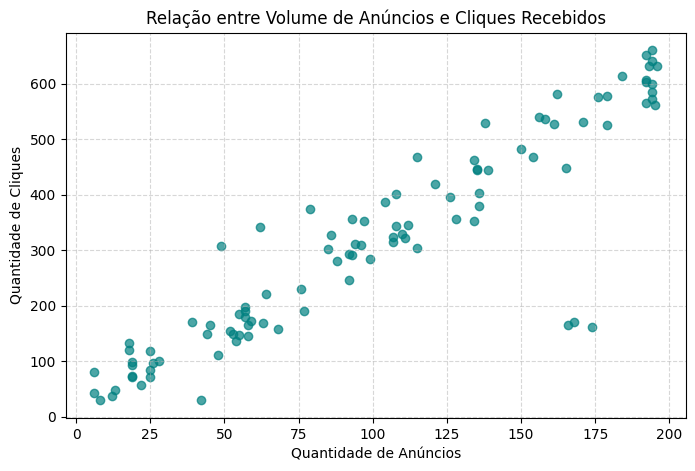


--- Matriz de Correlação ---
              anuncios   cliques  taxa_cliques  relevante
anuncios      1.000000  0.912057     -0.372015  -0.039934
cliques       0.912057  1.000000     -0.139317   0.205863
taxa_cliques -0.372015 -0.139317      1.000000   0.437905
relevante    -0.039934  0.205863      0.437905   1.000000


In [6]:
# ==========================================
# 2. Análise Exploratória de Dados (EDA)
# ==========================================
# Gráfico de dispersão Anúncios vs Cliques
plt.figure(figsize=(8, 5))
plt.scatter(dados['anuncios'], dados['cliques'], color='teal', alpha=0.7)
plt.title("Relação entre Volume de Anúncios e Cliques Recebidos")
plt.xlabel("Quantidade de Anúncios")
plt.ylabel("Quantidade de Cliques")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Verificação de multicolinearidade e correlação
print("\n--- Matriz de Correlação ---")
print(dados.corr())

In [7]:
# ==========================================
# 3. Divisão dos Dados (Treino e Teste)
# ==========================================
# Isolando a variável preditora (X) e a variável alvo (y)
X = dados[['anuncios']]
y = dados['relevante']

# Separação com proporção de 70/30
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42 # Ajustado o seed para uma nova distribuição aleatória
)

In [8]:
# ==========================================
# 4. Treinamento do Modelo
# ==========================================
classificador = LogisticRegression()
classificador.fit(X_treino, y_treino)

# Gerando as predições com o conjunto de teste
previsoes = classificador.predict(X_teste)


--- Métricas de Avaliação ---
Acurácia do Modelo: 0.6333

Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

       False       0.00      0.00      0.00        11
        True       0.63      1.00      0.78        19

    accuracy                           0.63        30
   macro avg       0.32      0.50      0.39        30
weighted avg       0.40      0.63      0.49        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


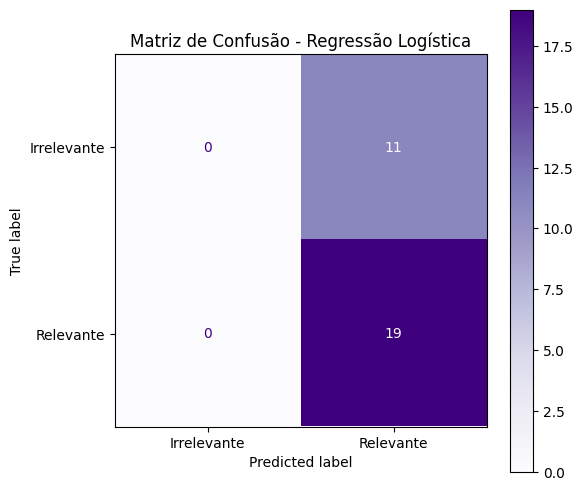

In [9]:
# ==========================================
# 5. Avaliação de Performance
# ==========================================
print("\n--- Métricas de Avaliação ---")
print(f"Acurácia do Modelo: {accuracy_score(y_teste, previsoes):.4f}\n")

print("Relatório de Classificação Detalhado:")
print(classification_report(y_teste, previsoes))

# Plotagem da Matriz de Confusão
matriz_confusao = confusion_matrix(y_teste, previsoes)

fig, ax = plt.subplots(figsize=(6, 6))
display_mc = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusao,
    display_labels=["Irrelevante", "Relevante"]
)
display_mc.plot(cmap="Purples", ax=ax, values_format='d')
plt.title("Matriz de Confusão - Regressão Logística")
plt.show()